In [2]:
"""ToxiGuard - BERT with Explanation Generator

**Goal**: Build a two-head model that classifies toxicity AND generates explanations + alternatives
"""

# Install required packages (run once)
# !pip install transformers torch datasets pandas scikit-learn tqdm

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertModel, GPT2Tokenizer, GPT2LMHeadModel
from transformers import get_linear_schedule_with_warmup
from torch.optim import AdamW
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')
import os
from datetime import datetime

# Check if GPU is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Set random seeds for reproducibility
def set_seed(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

Using device: cpu


In [4]:
print("="*60)
print("LOADING DATA FOR BERT")
print("="*60)

# Load the cleaned master dataset (only text, source, toxic)
df = pd.read_csv("../../data/processed/toxiguard_master_cleaned.csv")
print(f"Dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

# For BERT, we only need text and labels
text_column = 'text'
target_column = 'toxic'

# Prepare data - raw text only (BERT handles the rest)
X_text = df[text_column].values
y = df[target_column].values

print(f"\nText data shape: {X_text.shape}")
print(f"Target shape: {y.shape}")
print(f"Toxic: {sum(y==1)} | Non-toxic: {sum(y==0)}")
print(f"Toxic percentage: {sum(y==1)/len(y)*100:.2f}%")

# Split into train, validation, test
from sklearn.model_selection import train_test_split

# First split: separate test set (20%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X_text, y, test_size=0.2, random_state=42, stratify=y
)

# Second split: separate train and validation from remaining 80%
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.125, random_state=42, stratify=y_temp  # 0.125 * 0.8 = 0.1 of original
)

print("\n📊 Data split complete:")
print(f"  • Training: {len(X_train)} samples ({len(X_train)/len(y)*100:.1f}%)")
print(f"    - Toxic: {sum(y_train)} ({sum(y_train)/len(y_train)*100:.1f}%)")
print(f"  • Validation: {len(X_val)} samples ({len(X_val)/len(y)*100:.1f}%)") 
print(f"    - Toxic: {sum(y_val)} ({sum(y_val)/len(y_val)*100:.1f}%)")
print(f"  • Test: {len(X_test)} samples ({len(X_test)/len(y)*100:.1f}%)")
print(f"    - Toxic: {sum(y_test)} ({sum(y_test)/len(y_test)*100:.1f}%)")

print("\n✅ Data preparation complete!")

LOADING DATA FOR BERT
Dataset shape: (52768, 3)
Columns: ['text', 'toxic', 'source']

Text data shape: (52768,)
Target shape: (52768,)
Toxic: 25011 | Non-toxic: 27757
Toxic percentage: 47.40%

📊 Data split complete:
  • Training: 36937 samples (70.0%)
    - Toxic: 17508 (47.4%)
  • Validation: 5277 samples (10.0%)
    - Toxic: 2501 (47.4%)
  • Test: 10554 samples (20.0%)
    - Toxic: 5002 (47.4%)

✅ Data preparation complete!


In [5]:
print("="*60)
print("INITIALIZING BERT TOKENIZER AND MODEL")
print("="*60)

# Model name - using BERT base uncased (lowercase text)
model_name = 'bert-base-uncased'

# Initialize tokenizer
tokenizer = BertTokenizer.from_pretrained(model_name)
print(f"✅ Tokenizer loaded: {model_name}")
print(f"  Vocabulary size: {tokenizer.vocab_size}")
print(f"  Max length: {tokenizer.model_max_length}")

# Initialize BERT model for sequence classification
# We'll use it as base and add our own heads later
bert_model = BertModel.from_pretrained(model_name)
print(f"✅ BERT model loaded: {model_name}")
print(f"  Hidden size: {bert_model.config.hidden_size}")
print(f"  Number of layers: {bert_model.config.num_hidden_layers}")
print(f"  Number of attention heads: {bert_model.config.num_attention_heads}")

# Move model to device
bert_model = bert_model.to(device)
print(f"✅ Model moved to: {device}")

# Define maximum sequence length (BERT can handle up to 512)
max_length = 128  # Using 128 to save memory/time, adjust if needed
print(f"\nUsing max sequence length: {max_length}")

# Test tokenization on a sample
sample_text = X_train[0]
tokens = tokenizer.tokenize(sample_text)
token_ids = tokenizer.encode(sample_text, max_length=max_length, truncation=True)

print("📝 Tokenization example:")
print(f"  Original text: {sample_text[:100]}...")
print(f"  Number of tokens: {len(tokens)}")
print(f"  Token IDs (first 10): {token_ids[:10]}")
print(f"  Decoded back: {tokenizer.decode(token_ids[:20])}...")

INITIALIZING BERT TOKENIZER AND MODEL
✅ Tokenizer loaded: bert-base-uncased
  Vocabulary size: 30522
  Max length: 512


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 1363.81it/s]
BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ BERT model loaded: bert-base-uncased
  Hidden size: 768
  Number of layers: 12
  Number of attention heads: 12
✅ Model moved to: cpu

Using max sequence length: 128
📝 Tokenization example:
  Original text: I be lying in got theses bitches like u on my fuckin mind... but I be really focus just on this mone...
  Number of tokens: 30
  Token IDs (first 10): [101, 1045, 2022, 4688, 1999, 2288, 2122, 2015, 7743, 2229]
  Decoded back: [CLS] i be lying in got theses bitches like u on my fuckin mind......


In [6]:
print("="*60)
print("CREATING PYTORCH DATASET")
print("="*60)

class ToxicityDataset(Dataset):
    """Custom dataset for toxicity classification with BERT"""
    
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length
    
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]
        
        # Tokenize the text
        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )
        
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'label': torch.tensor(label, dtype=torch.long)
        }

# Create datasets
train_dataset = ToxicityDataset(X_train, y_train, tokenizer, max_length)
val_dataset = ToxicityDataset(X_val, y_val, tokenizer, max_length)
test_dataset = ToxicityDataset(X_test, y_test, tokenizer, max_length)

print(f"✅ Datasets created:")
print(f"  • Training: {len(train_dataset)} samples")
print(f"  • Validation: {len(val_dataset)} samples")
print(f"  • Test: {len(test_dataset)} samples")

# Create data loaders
batch_size = 16  # Adjust based on GPU memory

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"\n✅ Data loaders created with batch size: {batch_size}")
print(f"  • Training batches: {len(train_loader)}")
print(f"  • Validation batches: {len(val_loader)}")
print(f"  • Test batches: {len(test_loader)}")

# Test one batch
sample_batch = next(iter(train_loader))
print(f"\n📦 Sample batch:")
print(f"  • Input IDs shape: {sample_batch['input_ids'].shape}")
print(f"  • Attention mask shape: {sample_batch['attention_mask'].shape}")
print(f"  • Labels shape: {sample_batch['label'].shape}")

CREATING PYTORCH DATASET
✅ Datasets created:
  • Training: 36937 samples
  • Validation: 5277 samples
  • Test: 10554 samples

✅ Data loaders created with batch size: 16
  • Training batches: 2309
  • Validation batches: 330
  • Test batches: 660

📦 Sample batch:
  • Input IDs shape: torch.Size([16, 128])
  • Attention mask shape: torch.Size([16, 128])
  • Labels shape: torch.Size([16])


In [7]:
print("="*60)
print("BUILDING TOXIGUARD: BERT CLASSIFIER + GPT-2 EXPLAINER--Without fine-tuning")
print("="*60)

class ToxiGuard:
    """
    Two-stage Toxicity Detection System:
    1. BERT Classifier: Detects if comment is toxic
    2. GPT-2 Generator: If toxic, generates explanation + alternative
    """
    
    def __init__(self, bert_model, tokenizer, gpt2_model, gpt2_tokenizer, device):
        self.bert = bert_model
        self.tokenizer = tokenizer
        self.gpt2 = gpt2_model
        self.gpt2_tokenizer = gpt2_tokenizer
        self.device = device
        
        # Classification head
        self.classifier = nn.Sequential(
            nn.Dropout(0.1),
            nn.Linear(768, 256),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(256, 2)
        ).to(device)
        
    def classify(self, text):
        """Step 1: BERT classification"""
        # Tokenize input
        inputs = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=128,
            return_tensors='pt'
        ).to(self.device)
        
        # Get BERT embeddings
        with torch.no_grad():
            outputs = self.bert(**inputs)
            cls_embedding = outputs.last_hidden_state[:, 0, :]
            logits = self.classifier(cls_embedding)
            probs = torch.softmax(logits, dim=-1)
            prediction = torch.argmax(probs, dim=-1).item()
            confidence = probs[0][prediction].item()
        
        return prediction, confidence
    
    def generate_explanation(self, text):
        """Step 2: GPT-2 generates explanation and alternative"""
        # Construct prompt
        prompt = f"""
Comment: {text}

This comment is toxic because"""
        
        # Tokenize prompt
        inputs = self.gpt2_tokenizer(prompt, return_tensors='pt').to(self.device)
        
        # Generate
        with torch.no_grad():
            outputs = self.gpt2.generate(
                inputs.input_ids,
                max_new_tokens=100,
                temperature=0.7,
                do_sample=True,
                pad_token_id=self.gpt2_tokenizer.eos_token_id,
                eos_token_id=self.gpt2_tokenizer.eos_token_id
            )
        
        # Decode
        full_response = self.gpt2_tokenizer.decode(outputs[0], skip_special_tokens=True)
        
        # Extract the generated part (remove prompt)
        explanation = full_response.replace(prompt, "").strip()
        
        return explanation
    
    def predict(self, text):
        """Full pipeline: classify + generate if toxic"""
        prediction, confidence = self.classify(text)
        
        if prediction == 1:
            explanation = self.generate_explanation(text)
            return {
                'toxic': True,
                'confidence': confidence,
                'explanation': explanation
            }
        else:
            return {
                'toxic': False,
                'confidence': confidence,
                'message': 'Comment is safe'
            }

# Initialize the classifier (BERT + classification head)
bert_classifier = bert_model
classifier_head = nn.Sequential(
    nn.Dropout(0.1),
    nn.Linear(768, 256),
    nn.ReLU(),
    nn.Dropout(0.1),
    nn.Linear(256, 2)
).to(device)

# Initialize GPT-2 for generation
gpt2_model = GPT2LMHeadModel.from_pretrained('gpt2')
gpt2_tokenizer = GPT2Tokenizer.from_pretrained('gpt2')
gpt2_tokenizer.pad_token = gpt2_tokenizer.eos_token
gpt2_model = gpt2_model.to(device)
gpt2_model.eval()  # Set to evaluation mode

print("✅ BERT classifier ready")
print("✅ GPT-2 generator ready")

# Create ToxiGuard instance
toxiguard = ToxiGuard(bert_classifier, tokenizer, gpt2_model, gpt2_tokenizer, device)

# Test on a sample
print("\n🔍 Testing ToxiGuard (without fine-tuning) on sample comments:")
test_samples = [
    "You are an idiot!",
    "I respectfully disagree with your opinion",
    "Go kill yourself you worthless piece of trash",
    "Interesting perspective, thanks for sharing"
]

for sample in test_samples:
    result = toxiguard.predict(sample)
    print(f"\nInput: {sample}")
    if result['toxic']:
        print(f"  🔴 TOXIC (confidence: {result['confidence']:.3f})")
        print(f"  📝 {result['explanation']}")
    else:
        print(f"  🟢 NON-TOXIC (confidence: {result['confidence']:.3f})")
        print(f"  ✅ {result['message']}")
    print("-" * 50)

BUILDING TOXIGUARD: BERT CLASSIFIER + GPT-2 EXPLAINER--Without fine-tuning


Loading weights: 100%|██████████| 148/148 [00:00<00:00, 2840.85it/s]


✅ BERT classifier ready
✅ GPT-2 generator ready

🔍 Testing ToxiGuard (without fine-tuning) on sample comments:


The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.



Input: You are an idiot!
  🔴 TOXIC (confidence: 0.519)
  📝 it takes an idiot, who is a good person, to come out of the closet and say that her father had a violent relationship with his daughter and that he wanted her to go to a safe place. I am willing to bet that the next time she saw her father, she would have known that this was the case and that the father was a violent offender.

Comment: You are an asshole.

This comment is toxic because it takes a bad person who is a good person,
--------------------------------------------------

Input: I respectfully disagree with your opinion
  🔴 TOXIC (confidence: 0.532)
  📝 it does not explain why the person who had the discussion with you thought you were a good person to talk to. In fact, it suggests that the person you are talking to was not a good person at all. What you are saying is that you are not telling the truth. You are simply saying that you do not agree with the person who wrote this comment.

I will explain the logic of you

In [ ]:
###Since the two models were not fine-tuned to the actual data. It can be seen that their output is just random and not good.

In [ ]:
print("="*60)
print("TRAINING BERT CLASSIFIER (50% OF DATA)")
print("="*60)

# Take 50% of training data for faster training
subset_size = int(len(train_dataset) * 0.5)
subset_indices = np.random.choice(len(train_dataset), subset_size, replace=False)

from torch.utils.data import Subset
train_subset = Subset(train_dataset, subset_indices)
train_loader_subset = DataLoader(train_subset, batch_size=batch_size, shuffle=True)

print(f"Original training size: {len(train_dataset)}")
print(f"Subset training size (50%): {len(train_subset)}")
print(f"Training batches: {len(train_loader_subset)}")

# Define BERT Classifier model
class BertClassifier(nn.Module):
    def __init__(self, bert_model, num_classes=2):
        super(BertClassifier, self).__init__()
        self.bert = bert_model
        self.dropout = nn.Dropout(0.1)
        self.classifier = nn.Linear(768, num_classes)
        
    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls_embedding = outputs.last_hidden_state[:, 0, :]
        cls_embedding = self.dropout(cls_embedding)
        logits = self.classifier(cls_embedding)
        return logits

# Create model
bert_classifier = BertClassifier(bert_model).to(device)

# Optimizer
optimizer = AdamW(bert_classifier.parameters(), lr=2e-5, weight_decay=0.01)
criterion = nn.CrossEntropyLoss()

# Training loop
epochs = 3
best_val_acc = 0

for epoch in range(epochs):
    print(f"\nEpoch {epoch+1}/{epochs}")
    
    # Train
    bert_classifier.train()
    total_loss = 0
    correct = 0
    total = 0
    
    for batch in tqdm(train_loader_subset, desc="Training"):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)
        
        optimizer.zero_grad()
        logits = bert_classifier(input_ids, attention_mask)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        predictions = torch.argmax(logits, dim=-1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)
    
    train_acc = correct / total
    print(f"  Train Loss: {total_loss/len(train_loader_subset):.4f} | Train Acc: {train_acc:.4f}")
    
    # Validate
    bert_classifier.eval()
    correct = 0
    total = 0
    
    with torch.no_grad():
        for batch in tqdm(val_loader, desc="Validation"):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)
            
            logits = bert_classifier(input_ids, attention_mask)
            predictions = torch.argmax(logits, dim=-1)
            correct += (predictions == labels).sum().item()
            total += labels.size(0)
    
    val_acc = correct / total
    print(f"  Val Acc: {val_acc:.4f}")
    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(bert_classifier.state_dict(), '../../models/bert_classifier_best.pth')
        print(" Best model saved!")

print(f"\nBERT training complete! Best val accuracy: {best_val_acc:.4f}")

TRAINING BERT CLASSIFIER (50% OF DATA)
Original training size: 36937
Subset training size (50%): 18468
Training batches: 1155

Epoch 1/3


Training: 100%|██████████| 1155/1155 [6:11:03<00:00, 19.28s/it]  


  Train Loss: 0.1597 | Train Acc: 0.9382


Validation: 100%|██████████| 330/330 [23:22<00:00,  4.25s/it]


  Val Acc: 0.9593
 Best model saved!

Epoch 2/3


...

  Val Acc: 0.9576

Epoch 3/3


Training: 100%|██████████| 1155/1155 [6:10:51<00:00, 19.27s/it]  


  Train Loss: 0.0408 | Train Acc: 0.9856


Validation: 100%|██████████| 330/330 [23:59<00:00,  4.36s/it]

  Val Acc: 0.9532

BERT training complete! Best val accuracy: 0.9593


EVALUATING TRAINED BERT CLASSIFIER ON TEST SET
✅ Trained BERT classifier loaded!


Testing: 100%|██████████| 660/660 [56:59<00:00,  5.18s/it]  



📊 BERT Test Results:
  Accuracy: 0.9609

  Classification Report:
              precision    recall  f1-score   support

   Non-Toxic       0.96      0.96      0.96      5552
       Toxic       0.96      0.96      0.96      5002

    accuracy                           0.96     10554
   macro avg       0.96      0.96      0.96     10554
weighted avg       0.96      0.96      0.96     10554



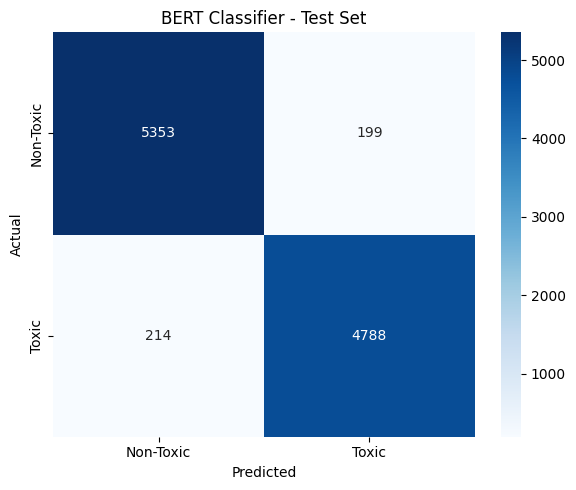

✅ Test results saved!


In [10]:
print("="*60)
print("EVALUATING TRAINED BERT CLASSIFIER ON TEST SET")
print("="*60)

# Load the trained model
class BertClassifier(nn.Module):
    def __init__(self, bert_model, num_classes=2):
        super(BertClassifier, self).__init__()
        self.bert = bert_model
        self.dropout = nn.Dropout(0.1)
        self.classifier = nn.Linear(768, num_classes)
        
    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls_embedding = outputs.last_hidden_state[:, 0, :]
        cls_embedding = self.dropout(cls_embedding)
        logits = self.classifier(cls_embedding)
        return logits

# Load best model
bert_classifier = BertClassifier(bert_model).to(device)
bert_classifier.load_state_dict(torch.load('../../models/bert_classifier_best.pth'))
bert_classifier.eval()
print("✅ Trained BERT classifier loaded!")

# Evaluate on test set
all_preds = []
all_labels = []

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Testing"):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)
        
        logits = bert_classifier(input_ids, attention_mask)
        preds = torch.argmax(logits, dim=-1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Metrics
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

accuracy = accuracy_score(all_labels, all_preds)
print(f"\n📊 BERT Test Results:")
print(f"  Accuracy: {accuracy:.4f}")
print(f"\n  Classification Report:")
print(classification_report(all_labels, all_preds, target_names=['Non-Toxic', 'Toxic']))

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Non-Toxic', 'Toxic'],
            yticklabels=['Non-Toxic', 'Toxic'])
plt.title('BERT Classifier - Test Set')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('../../results/figures/bert_test_confusion.png', dpi=300)
plt.show()

# Save results
test_results = pd.DataFrame({
    'text': X_test,
    'true_label': all_labels,
    'predicted_label': all_preds,
    'correct': np.array(all_labels) == np.array(all_preds)
})
test_results.to_csv('../../results/bert_test_results.csv', index=False)
print("✅ Test results saved!")

In [16]:
print("="*60)
print("PREPARING DATA FOR GPT-2 FINE-TUNING (WITH SUBSET)")
print("="*60)

# Get ALL toxic comments from training set
toxic_indices = np.where(y_train == 1)[0]
toxic_train_texts = X_train[toxic_indices]

print(f"Total toxic comments in training: {len(toxic_train_texts)}")

# Use 20% of toxic comments for faster training
use_toxic_samples = int(len(toxic_train_texts) * 0.2)  # ~4,000 samples
toxic_subset = np.random.choice(toxic_train_texts, use_toxic_samples, replace=False)

print(f"Using {len(toxic_subset)} toxic comments (20% of total)")

# Toxicity type maps
explanation_map = {
    'insult': "it contains a personal insult or name-calling.",
    'profanity': "it uses profane or offensive language.",
    'threat': "it contains threatening language or wishes harm.",
    'hate': "it expresses hatred towards a group or individual.",
    'harassment': "it is harassing or bullying in nature.",
    'aggressive': "it has an aggressive or hostile tone.",
    'disrespect': "it is disrespectful and attacks the person, not the idea.",
    'inappropriate': "it contains inappropriate or vulgar content."
}

alternative_map = {
    'insult': "I disagree with your point, but let's discuss respectfully.",
    'profanity': "Please express your opinion without using profanity.",
    'threat': "Let's keep the conversation constructive and respectful.",
    'hate': "We can disagree without resorting to hateful language.",
    'harassment': "Please communicate in a way that doesn't harass others.",
    'aggressive': "A calmer tone would make your point more effectively.",
    'disrespect': "Let's focus on the argument, not personal attacks.",
    'inappropriate': "Please rephrase your comment to be more appropriate."
}

def classify_toxicity_type(text):
    text_lower = text.lower()
    
    if any(word in text_lower for word in ['kill', 'die', 'hurt', 'harm', 'threat', 'murder']):
        return 'threat'
    elif any(word in text_lower for word in ['fuck', 'shit', 'damn', 'ass', 'bitch', 'cunt', 'dick']):
        return 'profanity'
    elif any(word in text_lower for word in ['idiot', 'stupid', 'dumb', 'moron', 'fool', 'retard']):
        return 'insult'
    elif any(word in text_lower for word in ['hate', 'racist', 'sexist', 'bigot', 'nazi', 'terrorist']):
        return 'hate'
    elif any(word in text_lower for word in ['harass', 'bully', 'stalk', 'intimidate']):
        return 'harassment'
    elif any(word in text_lower for word in ['angry', 'mad', 'rage', 'furious']):
        return 'aggressive'
    elif any(word in text_lower for word in ['disrespect', 'rude', 'ignorant', 'arrogant']):
        return 'disrespect'
    else:
        return 'inappropriate'

# Create training data
train_prompts = []
train_responses = []

print("\nCreating training examples...")
for comment in tqdm(toxic_subset, desc="Processing"):
    tox_type = classify_toxicity_type(comment)
    explanation = explanation_map[tox_type]
    alternative = alternative_map[tox_type]
    
    prompt = f"Comment: {comment}\n\nThis comment is toxic because"
    response = f" {explanation} Consider saying: {alternative}"
    
    train_prompts.append(prompt)
    train_responses.append(response)

print(f"\n✅ Created {len(train_prompts)} training examples")
print(f"\n📝 Example:")
print(f"  Prompt: {train_prompts[0][:150]}...")
print(f"  Response: {train_responses[0]}")

# Save
import pickle
with open('../../data/processed/gpt2_train_prompts.pkl', 'wb') as f:
    pickle.dump(train_prompts, f)
with open('../../data/processed/gpt2_train_responses.pkl', 'wb') as f:
    pickle.dump(train_responses, f)
print("\n✅ Training data saved!")

PREPARING DATA FOR GPT-2 FINE-TUNING (WITH SUBSET)
Total toxic comments in training: 17508
Using 3501 toxic comments (20% of total)

Creating training examples...


Processing: 100%|██████████| 3501/3501 [00:00<00:00, 33210.66it/s]


✅ Created 3501 training examples

📝 Example:
  Prompt: Comment: HAHA &#8220;@BASEDNAFRICAN: "If ANY of you bitches even THINK about attacking me in the elevator...." http://t.co/cp2C1iQria&#8221;

This com...
  Response:  it uses profane or offensive language. Consider saying: Please express your opinion without using profanity.

✅ Training data saved!


In [17]:
print("="*60)
print("CREATING GPT-2 DATASET")
print("="*60)

from torch.utils.data import Dataset, DataLoader

class GPT2FineTuneDataset(Dataset):
    def __init__(self, prompts, responses, tokenizer, max_length=200):
        self.prompts = prompts
        self.responses = responses
        self.tokenizer = tokenizer
        self.max_length = max_length
    
    def __len__(self):
        return len(self.prompts)
    
    def __getitem__(self, idx):
        full_text = self.prompts[idx] + self.responses[idx]
        
        encoding = self.tokenizer(
            full_text,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )
        
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten()
        }

# Load GPT-2 tokenizer
print("Loading GPT-2 tokenizer...")
from transformers import GPT2Tokenizer
gpt2_tokenizer = GPT2Tokenizer.from_pretrained('gpt2')
gpt2_tokenizer.pad_token = gpt2_tokenizer.eos_token

# Create dataset
gpt2_train_dataset = GPT2FineTuneDataset(train_prompts, train_responses, gpt2_tokenizer)
gpt2_train_loader = DataLoader(gpt2_train_dataset, batch_size=4, shuffle=True)

print(f"✅ Dataset created: {len(gpt2_train_dataset)} samples")
print(f"   Batches: {len(gpt2_train_loader)}")

CREATING GPT-2 DATASET
Loading GPT-2 tokenizer...
✅ Dataset created: 3501 samples
   Batches: 876


In [18]:
print("="*60)
print("FINE-TUNING GPT-2")
print("="*60)

from transformers import GPT2LMHeadModel
from torch.optim import AdamW
import torch

# Load GPT-2 model
print("Loading GPT-2 model...")
gpt2_model = GPT2LMHeadModel.from_pretrained('gpt2')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
gpt2_model = gpt2_model.to(device)

# Optimizer
optimizer_gpt2 = AdamW(gpt2_model.parameters(), lr=5e-5)

# Fine-tuning loop
epochs_gpt2 = 2
print(f"\n🚀 Starting GPT-2 fine-tuning ({epochs_gpt2} epochs)...")

for epoch in range(epochs_gpt2):
    print(f"\n{'='*50}")
    print(f"Epoch {epoch+1}/{epochs_gpt2}")
    print(f"{'='*50}")
    
    gpt2_model.train()
    total_loss = 0
    
    for batch in tqdm(gpt2_train_loader, desc="Training GPT-2"):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        
        outputs = gpt2_model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=input_ids
        )
        
        loss = outputs.loss
        optimizer_gpt2.zero_grad()
        loss.backward()
        optimizer_gpt2.step()
        
        total_loss += loss.item()
    
    avg_loss = total_loss / len(gpt2_train_loader)
    print(f"\n📊 Epoch {epoch+1} complete!")
    print(f"   Average Loss: {avg_loss:.4f}")

# Save fine-tuned model
print("\n💾 Saving fine-tuned GPT-2...")
gpt2_model.save_pretrained('../../models/gpt2_toxiguard_finetuned')
gpt2_tokenizer.save_pretrained('../../models/gpt2_toxiguard_finetuned')
print("✅ GPT-2 fine-tuned model saved!")

FINE-TUNING GPT-2
Loading GPT-2 model...


Loading weights: 100%|██████████| 148/148 [00:00<00:00, 1112.07it/s]



🚀 Starting GPT-2 fine-tuning (2 epochs)...

Epoch 1/2


Training GPT-2: 100%|██████████| 876/876 [3:53:50<00:00, 16.02s/it]    



📊 Epoch 1 complete!
   Average Loss: 0.6429

Epoch 2/2


Training GPT-2: 100%|██████████| 876/876 [3:22:01<00:00, 13.84s/it]  



📊 Epoch 2 complete!
   Average Loss: 0.5401

💾 Saving fine-tuned GPT-2...


Writing model shards: 100%|██████████| 1/1 [00:03<00:00,  3.38s/it]


✅ GPT-2 fine-tuned model saved!


In [3]:
print("="*60)
print("TESTING FINE-TUNED GPT-2")
print("="*60)

# Load fine-tuned model
print("Loading fine-tuned GPT-2...")
from transformers import GPT2LMHeadModel, GPT2Tokenizer

gpt2_finetuned = GPT2LMHeadModel.from_pretrained('../../models/gpt2_toxiguard_finetuned')
gpt2_finetuned_tokenizer = GPT2Tokenizer.from_pretrained('../../models/gpt2_toxiguard_finetuned')
gpt2_finetuned = gpt2_finetuned.to(device)
gpt2_finetuned.eval()

print("✅ Fine-tuned GPT-2 loaded!")

# Test samples
test_comments = [
    "You are an idiot!",
    "Go kill yourself you worthless trash",
    "This is fucking garbage",
    "I hate all of you racist bigots",
    "Your article is disrespectful and ignorant"
]

print("\n🔍 GENERATION TEST:\n")

for comment in test_comments:
    prompt = f"Comment: {comment}\n\nThis comment is toxic because"
    inputs = gpt2_finetuned_tokenizer(prompt, return_tensors='pt').to(device)
    
    with torch.no_grad():
        outputs = gpt2_finetuned.generate(
            inputs.input_ids,
            max_new_tokens=80,
            temperature=0.7,
            do_sample=True,
            pad_token_id=gpt2_finetuned_tokenizer.eos_token_id
        )
    
    full_response = gpt2_finetuned_tokenizer.decode(outputs[0], skip_special_tokens=True)
    explanation = full_response.replace(prompt, "").strip()
    
    print(f"Comment: {comment}")
    print(f"📝 Generated: {explanation}")
    print("-" * 70)

TESTING FINE-TUNED GPT-2
Loading fine-tuned GPT-2...


Loading weights: 100%|██████████| 148/148 [00:00<00:00, 1313.72it/s]
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


✅ Fine-tuned GPT-2 loaded!

🔍 GENERATION TEST:

Comment: You are an idiot!
📝 Generated: it contains inappropriate or vulgar content. Consider saying: Please rephrase your comment to be more appropriate.
----------------------------------------------------------------------
Comment: Go kill yourself you worthless trash
📝 Generated: it contains a personal insult or name-calling. Consider saying: I disagree with your point, but let's discuss respectfully.
----------------------------------------------------------------------
Comment: This is fucking garbage
📝 Generated: it uses profane or offensive language. Consider saying: Please express your opinion without using profanity.
----------------------------------------------------------------------
Comment: I hate all of you racist bigots
📝 Generated: it contains a personal insult or name-calling. Consider saying: I disagree with your point, but let's discuss respectfully.
--------------------------------------------------------------------

In [5]:
print("="*60)
print("TOXIGUARD FINAL - WITH TRAINED MODELS")
print("="*60)

import torch
import pandas as pd
import pickle
from transformers import BertModel, BertTokenizer, GPT2LMHeadModel, GPT2Tokenizer
from tqdm import tqdm
import torch.nn as nn

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Load BERT tokenizer
bert_tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

# Load trained BERT classifier
class TrainedBertClassifier(nn.Module):
    def __init__(self, bert_model, num_classes=2):
        super(TrainedBertClassifier, self).__init__()
        self.bert = bert_model
        self.dropout = nn.Dropout(0.1)
        self.classifier = nn.Linear(768, num_classes)
        
    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls_embedding = outputs.last_hidden_state[:, 0, :]
        cls_embedding = self.dropout(cls_embedding)
        logits = self.classifier(cls_embedding)
        return logits

# Load BERT model
bert_base = BertModel.from_pretrained('bert-base-uncased')
bert_classifier = TrainedBertClassifier(bert_base).to(device)
bert_classifier.load_state_dict(torch.load('../../models/bert_classifier_best.pth', map_location=device))
bert_classifier.eval()
print("✅ Trained BERT classifier loaded")

# Load fine-tuned GPT-2
gpt2_model = GPT2LMHeadModel.from_pretrained('../../models/gpt2_toxiguard_finetuned')
gpt2_tokenizer = GPT2Tokenizer.from_pretrained('../../models/gpt2_toxiguard_finetuned')
gpt2_model = gpt2_model.to(device)
gpt2_model.eval()
print("✅ Fine-tuned GPT-2 loaded")

# FINAL TOXIGUARD CLASS (with trained models)
class ToxiGuardFinal:
    def __init__(self, bert_model, bert_tokenizer, gpt2_model, gpt2_tokenizer, device):
        self.bert = bert_model
        self.bert_tokenizer = bert_tokenizer
        self.gpt2 = gpt2_model
        self.gpt2_tokenizer = gpt2_tokenizer
        self.device = device
    
    def classify(self, text):
        inputs = self.bert_tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=128,
            return_tensors='pt'
        ).to(self.device)
        
        with torch.no_grad():
            logits = self.bert(inputs['input_ids'], inputs['attention_mask'])
            probs = torch.softmax(logits, dim=-1)
            prediction = torch.argmax(probs, dim=-1).item()
            confidence = probs[0][prediction].item()
        
        return prediction, confidence
    
    def generate_explanation(self, text):
        prompt = f"Comment: {text}\n\nThis comment is toxic because"
        inputs = self.gpt2_tokenizer(prompt, return_tensors='pt').to(self.device)
        
        with torch.no_grad():
            outputs = self.gpt2.generate(
                inputs.input_ids,
                max_new_tokens=80,
                temperature=0.7,
                do_sample=True,
                pad_token_id=self.gpt2_tokenizer.eos_token_id
            )
        
        full_response = self.gpt2_tokenizer.decode(outputs[0], skip_special_tokens=True)
        explanation = full_response.replace(prompt, "").strip()
        
        return explanation
    
    def predict(self, text):
        prediction, confidence = self.classify(text)
        
        if prediction == 1:
            explanation = self.generate_explanation(text)
            return {
                'toxic': True,
                'confidence': confidence,
                'explanation': explanation
            }
        else:
            return {
                'toxic': False,
                'confidence': confidence,
                'message': 'Comment is safe'
            }

# Create ToxiGuard instance
toxiguard_final = ToxiGuardFinal(bert_classifier, bert_tokenizer, gpt2_model, gpt2_tokenizer, device)
print("✅ ToxiGuard Final ready!")

# Test on a sample
print("\n🔍 Testing ToxiGuard Final on sample comments:")
test_samples = [
    "You are an idiot!",
    "I respectfully disagree with your opinion",
    "Go kill yourself you worthless piece of trash",
    "Interesting perspective, thanks for sharing"
]

for sample in test_samples:
    result = toxiguard_final.predict(sample)
    print(f"\nInput: {sample}")
    if result['toxic']:
        print(f"  🔴 TOXIC (confidence: {result['confidence']:.3f})")
        print(f"  📝 {result['explanation']}")
    else:
        print(f"  🟢 NON-TOXIC (confidence: {result['confidence']:.3f})")
        print(f"  ✅ {result['message']}")
    print("-" * 50)

# Save the final model
print("\n💾 Saving ToxiGuard Final...")
with open('../../models/toxiguard_final.pkl', 'wb') as f:
    pickle.dump(toxiguard_final, f)
print("✅ ToxiGuard Final saved to: models/toxiguard_final.pkl")

# Also save components
torch.save(bert_classifier.state_dict(), '../../models/bert_classifier_toxiguard_final.pth')
gpt2_model.save_pretrained('../../models/gpt2_toxiguard_final')
gpt2_tokenizer.save_pretrained('../../models/gpt2_toxiguard_final')
print("✅ Individual components saved")

TOXIGUARD FINAL - WITH TRAINED MODELS
Using device: cpu


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 1101.31it/s]
BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Trained BERT classifier loaded


Loading weights: 100%|██████████| 148/148 [00:00<00:00, 1278.90it/s]


✅ Fine-tuned GPT-2 loaded
✅ ToxiGuard Final ready!

🔍 Testing ToxiGuard Final on sample comments:

Input: You are an idiot!
  🔴 TOXIC (confidence: 0.994)
  📝 it contains a personal insult or name-calling. Consider saying: I disagree with your point, but let's discuss respectfully.
--------------------------------------------------

Input: I respectfully disagree with your opinion
  🟢 NON-TOXIC (confidence: 0.998)
  ✅ Comment is safe
--------------------------------------------------

Input: Go kill yourself you worthless piece of trash
  🔴 TOXIC (confidence: 0.988)
  📝 it contains inappropriate or vulgar content. Consider saying: Please rephrase your comment to be more appropriate.
--------------------------------------------------

Input: Interesting perspective, thanks for sharing
  🟢 NON-TOXIC (confidence: 0.999)
  ✅ Comment is safe
--------------------------------------------------

💾 Saving ToxiGuard Final...
✅ ToxiGuard Final saved to: models/toxiguard_final.pkl


Writing model shards: 100%|██████████| 1/1 [00:21<00:00, 21.94s/it]


✅ Individual components saved
